#导入库与读取数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl
from datetime import datetime

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['font.family'] = 'sans-serif'   

df = pd.read_excel("Online Retail.xlsx")  

print("✅ 数据读取成功！数据集基本信息：")
print(f"数据总行数：{df.shape[0]}，总列数：{df.shape[1]}")
print("\n前5行数据预览：")
print(df.head()) 

✅ 数据读取成功！数据集基本信息：
数据总行数：541909，总列数：8

前5行数据预览：
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


#数据清洗（缺失值、异常值处理）

In [2]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]mm
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
print("✅ 数据清洗完成！") 

✅ 数据清洗完成！


#计算RFM指标

In [3]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()
print("✅ RFM指标计算完成！")
print(rfm.head()) 

✅ RFM指标计算完成！
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


#RFM打分与客户分层

In [4]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >=4 and f >=4 and m >=4:
        return '高价值核心客户'
    elif r >=3 and f >=3 and m >=3:
        return '潜力发展客户'
    elif r >=4 and f <=2 and m <=2:
        return '新客户'
    elif r <=2 and f >=3 and m >=3:
        return '流失高价值客户'
    elif r <=2 and f <=2 and m <=2:
        return '低价值/沉睡客户'
    else:
        return '一般客户'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)
print("✅ 客户分层完成！")
print(rfm['Customer_Segment'].value_counts())

✅ 客户分层完成！
Customer_Segment
一般客户        1106
高价值核心客户      962
低价值/沉睡客户     824
潜力发展客户       758
流失高价值客户      454
新客户          234
Name: count, dtype: int64


#可视化分析

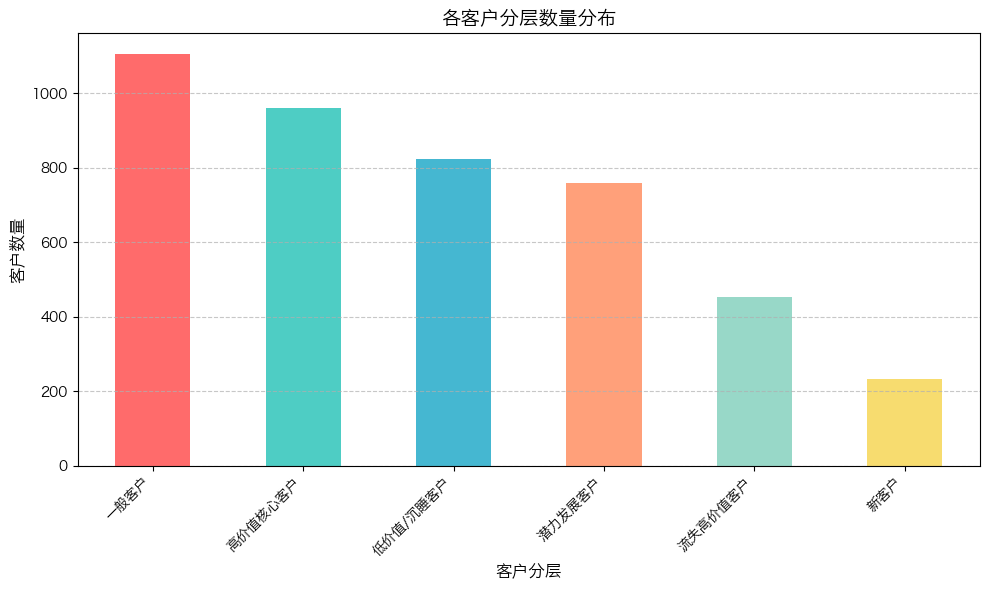

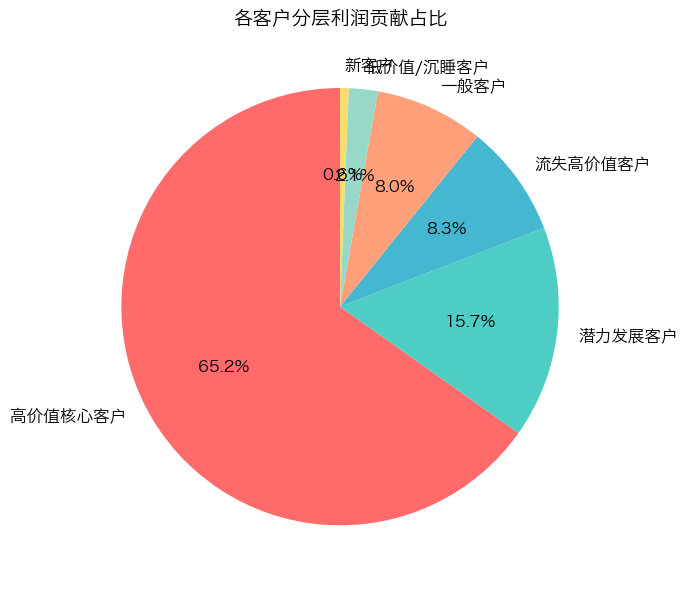

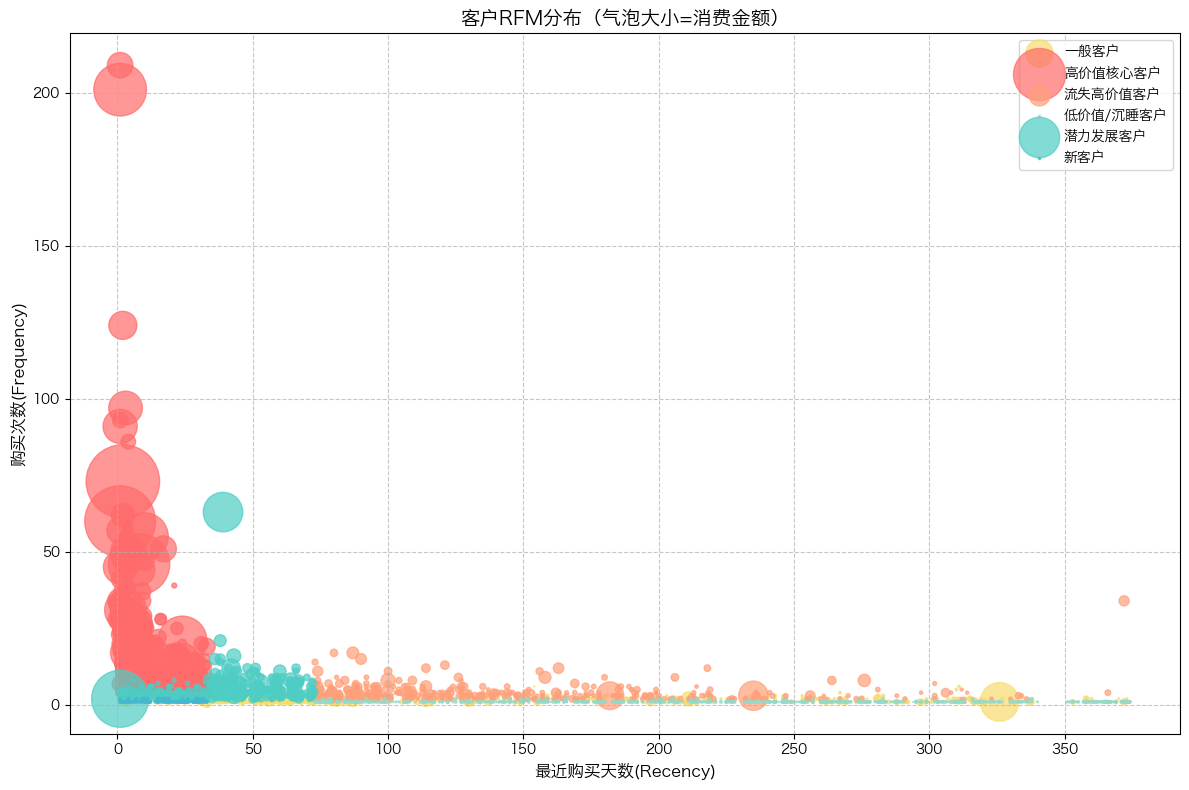

In [5]:
plt.figure(figsize=(10, 6))
segment_counts = rfm['Customer_Segment'].value_counts().sort_values(ascending=False)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
segment_counts.plot(kind='bar', color=colors)
plt.title('各客户分层数量分布', fontsize=14, fontweight='bold')
plt.xlabel('客户分层', fontsize=12)
plt.ylabel('客户数量', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('客户分层数量分布.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
segment_profit = rfm.groupby('Customer_Segment')['Monetary'].sum().sort_values(ascending=False)
segment_profit.plot(kind='pie', autopct='%.1f%%', startangle=90, colors=colors, textprops={'fontsize':12})
plt.title('各客户分层利润贡献占比', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('客户分层利润贡献.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 8))
color_map = {
    '高价值核心客户':'#FF6B6B', 
    '潜力发展客户':'#4ECDC4', 
    '新客户':'#45B7D1', 
    '流失高价值客户':'#FFA07A', 
    '低价值/沉睡客户':'#98D8C8', 
    '一般客户':'#F7DC6F'
}
for segment in rfm['Customer_Segment'].unique():
    subset = rfm[rfm['Customer_Segment'] == segment]
    plt.scatter(
        subset['Recency'], subset['Frequency'], 
        s=subset['Monetary']/100,  
        c=color_map[segment], label=segment, alpha=0.7
    )
plt.xlabel('最近购买天数(Recency)', fontsize=12)
plt.ylabel('购买次数(Frequency)', fontsize=12)
plt.title('客户RFM分布（气泡大小=消费金额）', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('RFM客户分布散点图.png', dpi=300, bbox_inches='tight')
plt.show()